# HATR cross-framework — Qualità di regressione

Confronto di `HoeffdingAdaptiveTreeRegressor` in River e CapyMOA su 4 dataset in prequential evaluation, con due configurazioni: deterministica (`mean`, no bootstrap) per misurare la consistenza, e default (`adaptive`, bootstrap) per la qualità realistica.

## Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel → Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 10000
SYN_N, SYN_DRIFT = 10000, 5000

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]      = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]     = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]     = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<10} n={len(X):>6}  feat={X.shape[1]:>2}  y∈[{y.min():.2f}, {y.max():.2f}]")

Synthetic  n= 10000  feat= 5  y∈[-14.45, 15.29]
Bike       n= 10000  feat=12  y∈[1.00, 651.00]
Fried      n= 10000  feat=10  y∈[-1.23, 29.11]
Hyper      n= 10000  feat=10  y∈[105.39, 580.72]


## Parametri

In [3]:
BASE = dict(grace_period=50, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=300, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.002, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True
SKIP  = 50

## Esecuzione

In [4]:
rows = []
preds_cache = {}   # (dataset, config) -> (yt, river_pred, capy_pred)

for ds_name, (X, y, schema) in datasets.items():
    for cfg_name, cfg in CONFIGS.items():
        rp, _ = utils.prequential_river(X, y, cfg, BASE, scale=SCALE)
        cp, _ = utils.prequential_capy(X, y, schema, cfg, BASE, scale=SCALE)
        preds_cache[(ds_name, cfg_name)] = (y, rp, cp)
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="River",
                         MAE=utils.mae(y[SKIP:], rp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], rp[SKIP:]),
                         R2=utils.r2(y[SKIP:], rp[SKIP:])))
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="CapyMOA",
                         MAE=utils.mae(y[SKIP:], cp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], cp[SKIP:]),
                         R2=utils.r2(y[SKIP:], cp[SKIP:])))
        print(f"  {ds_name:<10} | {cfg_name:<32} | done")

results = pd.DataFrame(rows)
print("\nRisultati completi:")
results

  Synthetic  | deterministic (mean, no-bootstrap) | done
  Synthetic  | default (adaptive, bootstrap)    | done
  Bike       | deterministic (mean, no-bootstrap) | done
  Bike       | default (adaptive, bootstrap)    | done
  Fried      | deterministic (mean, no-bootstrap) | done
  Fried      | default (adaptive, bootstrap)    | done
  Hyper      | deterministic (mean, no-bootstrap) | done
  Hyper      | default (adaptive, bootstrap)    | done

Risultati completi:


,dataset,config,framework,MAE,RMSE,R2
0,Synthetic,"deterministic (mean, no-bootstrap)",River,1.027336,1.581170,0.826360
1,Synthetic,"deterministic (mean, no-bootstrap)",CapyMOA,1.027336,1.581170,0.826360
2,Synthetic,"default (adaptive, bootstrap)",River,0.274229,0.539937,0.979752
3,Synthetic,"default (adaptive, bootstrap)",CapyMOA,0.244570,0.502545,0.982459
4,Bike,"deterministic (mean, no-bootstrap)",River,63.936948,92.211526,0.518703
5,Bike,"deterministic (mean, no-bootstrap)",CapyMOA,63.936948,92.211526,0.518703
6,Bike,"default (adaptive, bootstrap)",River,59.040542,128.645993,0.063226
7,Bike,"default (adaptive, bootstrap)",CapyMOA,49.282891,75.961558,0.673389
8,Fried,"deterministic (mean, no-bootstrap)",River,2.628401,3.292789,0.561262
9,Fried,"deterministic (mean, no-bootstrap)",CapyMOA,2.628401,3.292789,0.561262


## Qualità

In [5]:
pivot = results.pivot_table(index=["dataset", "config"], columns="framework",
                            values=["MAE", "RMSE", "R2"])
pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pivot

framework                                    CapyMOA                  River  \
                                                 MAE     R2    RMSE     MAE   
dataset   config                                                              
Bike      default (adaptive, bootstrap)      49.2829 0.6734 75.9616 59.0405   
          deterministic (mean, no-bootstrap) 63.9369 0.5187 92.2115 63.9369   
Fried     default (adaptive, bootstrap)       1.9332 0.7454  2.5081  1.9490   
          deterministic (mean, no-bootstrap)  2.6284 0.5613  3.2928  2.6284   
Hyper     default (adaptive, bootstrap)       9.6694 0.9290 18.5817  7.4546   
          deterministic (mean, no-bootstrap) 43.2640 0.3884 54.5418 43.2640   
Synthetic default (adaptive, bootstrap)       0.2446 0.9825  0.5025  0.2742   
          deterministic (mean, no-bootstrap)  1.0273 0.8264  1.5812  1.0273   

framework                                                     
                                                 R2     RMSE  
dataset   config                                              
Bike      default (adaptive, bootstrap)      0.0632 128.6460  
          deterministic (mean, no-bootstrap) 0.5187  92.2115  
Fried     default (adaptive, bootstrap)      0.7455   2.5079  
          deterministic (mean, no-bootstrap) 0.5613   3.2928  
Hyper     default (adaptive, bootstrap)      0.9620  13.6031  
          deterministic (mean, no-bootstrap) 0.3884  54.5418  
Synthetic default (adaptive, bootstrap)      0.9798   0.5399  
          deterministic (mean, no-bootstrap) 0.8264   1.5812

## Grafici

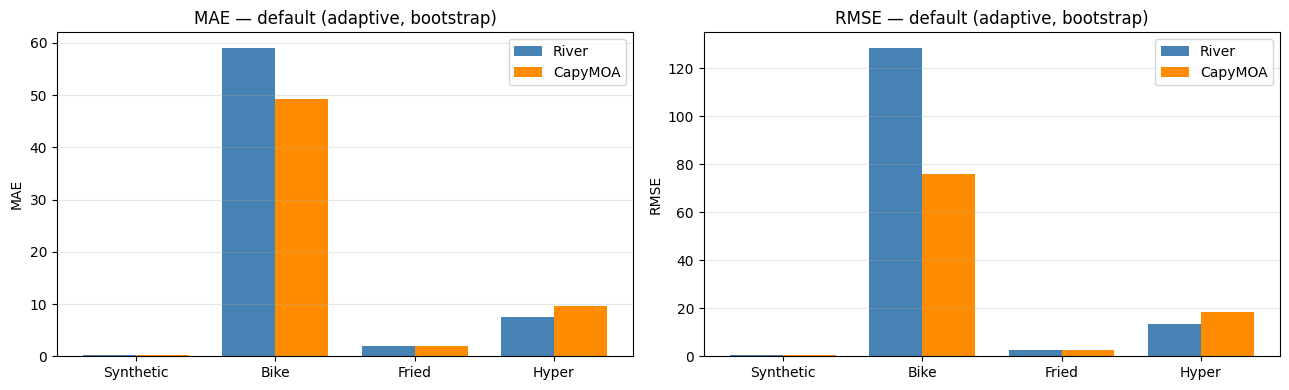

In [6]:
cfg_plot = "default (adaptive, bootstrap)"
sub = results[results.config == cfg_plot]
ds_order = list(datasets.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    rv = [sub[(sub.dataset == d) & (sub.framework == "River")][metric].values[0] for d in ds_order]
    cm = [sub[(sub.dataset == d) & (sub.framework == "CapyMOA")][metric].values[0] for d in ds_order]
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River", color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order)
    ax.set_ylabel(metric); ax.set_title(f"{metric} — {cfg_plot}")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Consistenza (deterministico)

In [7]:
cfg_det = "deterministic (mean, no-bootstrap)"
cons = []
for ds_name in datasets.keys():
    yt, rp, cp = preds_cache[(ds_name, cfg_det)]
    d = np.abs(rp - cp)
    corr = np.corrcoef(rp[SKIP:], cp[SKIP:])[0, 1]
    cons.append(dict(dataset=ds_name,
                     corr=corr, max_abs_diff=d.max(), mean_abs_diff=d.mean(),
                     frac_diff_lt_1e6=float(np.mean(d < 1e-6)),
                     MAE_river=utils.mae(yt[SKIP:], rp[SKIP:]),
                     MAE_capy=utils.mae(yt[SKIP:], cp[SKIP:]),
                     dMAE=abs(utils.mae(yt[SKIP:], rp[SKIP:]) - utils.mae(yt[SKIP:], cp[SKIP:]))))
cons_df = pd.DataFrame(cons)
print("Consistenza (mean, no bootstrap):")
cons_df

Consistenza (mean, no bootstrap):


,dataset,corr,max_abs_diff,mean_abs_diff,frac_diff_lt_1e6,MAE_river,MAE_capy,dMAE
0,Synthetic,1.0000,0.0000,0.0000,1.0000,1.0273,1.0273,0.0000
1,Bike,1.0000,0.0000,0.0000,1.0000,63.9369,63.9369,0.0000
2,Fried,1.0000,0.0000,0.0000,1.0000,2.6284,2.6284,0.0000
3,Hyper,1.0000,0.0000,0.0000,1.0000,43.2640,43.2640,0.0000


## Discussione

**Modalità deterministica (`mean`, no bootstrap).** Le implementazioni condividono lo stesso algoritmo; ci si aspettano predizioni identiche (corr ≈ 1, delta_MAE ≈ 0).

**Modalità default (`adaptive` + bootstrap).** Le RNG divergono (Python MT vs `java.util.Random`): le predizioni puntuali non coincidono, ma MAE/RMSE aggregati restano vicini. Per valutare la qualità reale è questo il confronto corretto.

**Standardizzazione.** `SCALE=True` applica lo stesso `StandardScaler` online a entrambi i lati; non introduce asimmetrie.